In [72]:
import numpy as np
import pandas as pd
df=pd.read_csv(r'/content/drive/MyDrive/Datasets/heart_failure_clinical_records_dataset.csv')
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [73]:
df.dtypes

,0
age,float64
anaemia,int64
creatinine_phosphokinase,int64
diabetes,int64
ejection_fraction,int64
high_blood_pressure,int64
platelets,float64
serum_creatinine,float64
serum_sodium,int64
sex,int64


In [74]:
x=df.drop(columns='DEATH_EVENT')
y=df['DEATH_EVENT']

In [75]:
from sklearn.model_selection import train_test_split
x_tr,x_te,y_tr,y_te=train_test_split(x,y,test_size=0.30,random_state=13)

In [76]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier(random_state=11)
dtc.fit(x_tr,y_tr)


DecisionTreeClassifier(random_state=11)

In [77]:
y_pred=dtc.predict(x_te)

In [78]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
print(classification_report(y_te,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89        62
           1       0.75      0.75      0.75        28

    accuracy                           0.84        90
   macro avg       0.82      0.82      0.82        90
weighted avg       0.84      0.84      0.84        90



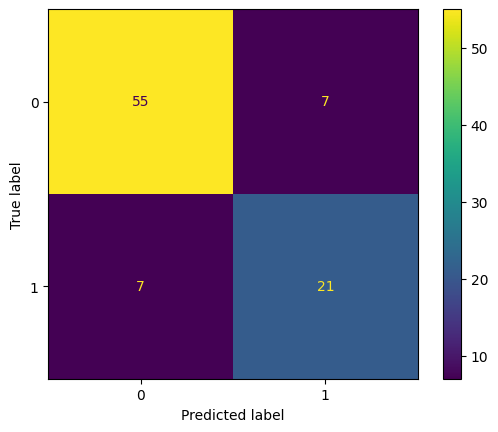

In [79]:
print(ConfusionMatrixDisplay.from_predictions(y_te,y_pred))

In [80]:
dtc.score(x_tr,y_tr)

1.0

In [92]:
dtc.score(x_te,y_te)

0.8444444444444444

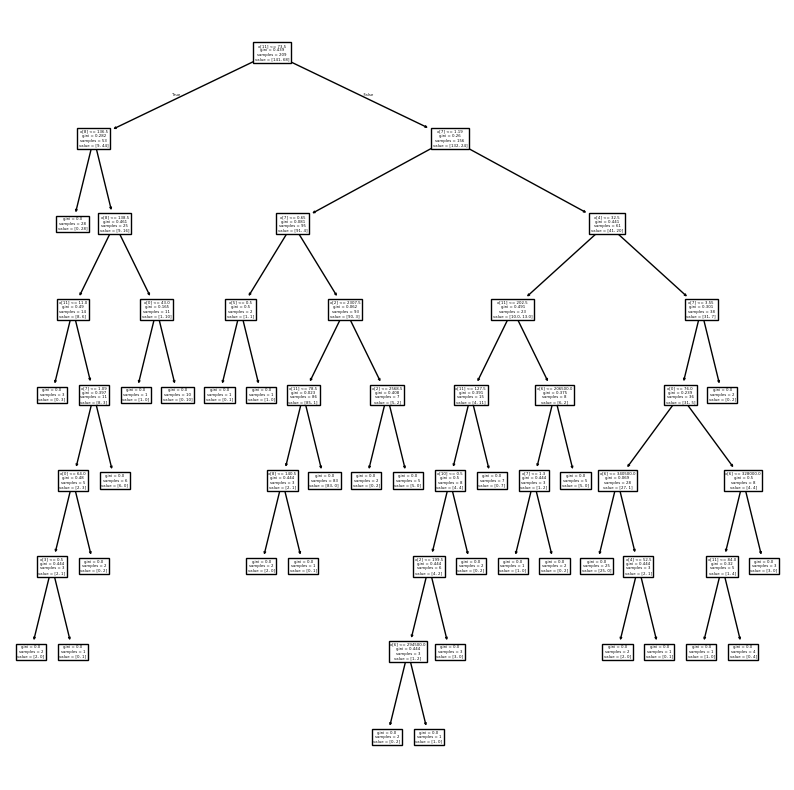

In [84]:
from sklearn import tree
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
tree.plot_tree(dtc)
plt.show()

In [85]:
from imblearn.over_sampling import SMOTE
os=SMOTE(random_state=11)
x_os,y_os=os.fit_resample(x_tr,y_tr)

In [86]:
dtc1=DecisionTreeClassifier(random_state=11)
dtc1.fit(x_os,y_os)
y_pred1=dtc1.predict(x_te)

In [87]:
print(classification_report(y_te,y_pred1))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        62
           1       0.71      0.71      0.71        28

    accuracy                           0.82        90
   macro avg       0.79      0.79      0.79        90
weighted avg       0.82      0.82      0.82        90



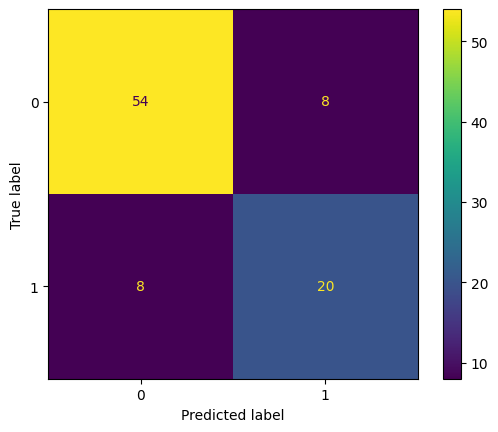

In [88]:
print(ConfusionMatrixDisplay.from_predictions(y_te,y_pred1))

In [89]:
dtc1.score(x_os,y_os)

1.0

In [91]:
dtc1.score(x_te,y_te)

0.8222222222222222

In [93]:
from imblearn.under_sampling import RandomUnderSampler
us=RandomUnderSampler(random_state=11)

In [94]:
x_us,y_us=us.fit_resample(x_tr,y_tr)

In [96]:
dtcus=DecisionTreeClassifier(random_state=11)
dtcus.fit(x_us,y_us)

,count
DEATH_EVENT,
0,68
1,68


In [97]:
y_pred_us=dtcus.predict(x_te)

In [98]:
print(classification_report(y_te,y_pred_us))

              precision    recall  f1-score   support

           0       0.86      0.81      0.83        62
           1       0.62      0.71      0.67        28

    accuracy                           0.78        90
   macro avg       0.74      0.76      0.75        90
weighted avg       0.79      0.78      0.78        90



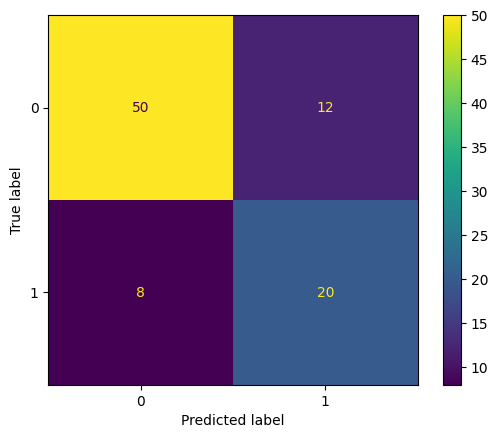

In [99]:
print(ConfusionMatrixDisplay.from_predictions(y_te,y_pred_us))